In [7]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.optimize as optimize

In [8]:
# Load the data
filename = 'FrequencyAndTimeDelayData_20260409_122947_Traces.csv'
data = np.loadtxt(filename, skiprows=9, delimiter=",")

freqs = data[:,0]
omegas = 2 * np.pi * freqs
amp = data[:,1]
phase = data[:,2]

# Note that you can use freqs and omegas interchangeably, since they are just 
# related by a constant factor, and each element/index corresponds to the same
# data point. We'll use the omegas for fitting since the model is expressed in
# terms of omega, but use freqs for plotting since it's more intuitive to think 
# about frequencies in Hz.

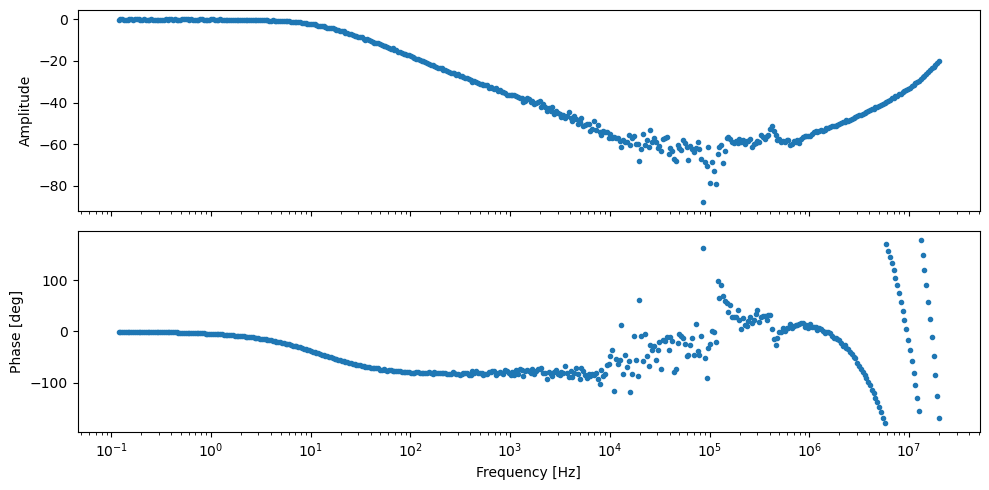

In [29]:
# Plot your raw data to see what it looks like
# Plot your fits
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(freqs, amp, '.')
ax[0].set_ylabel('Amplitude')
ax[0].set_xscale('log')

ax[1].plot(freqs, phase, '.')
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel('Phase [deg]')

fig.tight_layout()
plt.show()

In [17]:
# To use the models defined in the lab manual, we need to convert the amplitude response
# to absolute amplitude rather than dB.
amp_abs = 10.0**(amp/20.0)

# Noting that 360 degree phase shift is also 0 phase shift, we'll offset our phase data,
# as well as convert it to radians for fitting, since the model is expressed in radians.
phase_rad = np.deg2rad(phase)

In [18]:
# Define the ideal model
def amp_response(omega, omega_c):
    return 1/np.sqrt(1 + (omega/omega_c)**2)

def phase_response(omega, omega_c):
    return -1.0*np.arctan2(omega, omega_c)

In [34]:
# Fit the data to the model, with optional masking to exclude some data
omega_c_guess = 100.0

mask = (freqs > 1) & (freqs < 1e4)  # Example mask to exclude very low and very high frequencies, adjust as needed

popt_amp, pcov_amp = optimize.curve_fit(amp_response, omegas[mask], amp_abs[mask], p0=[omega_c_guess])
popt_phase, pcov_phase = optimize.curve_fit(phase_response, omegas[mask], phase_rad[mask], p0=[omega_c_guess])

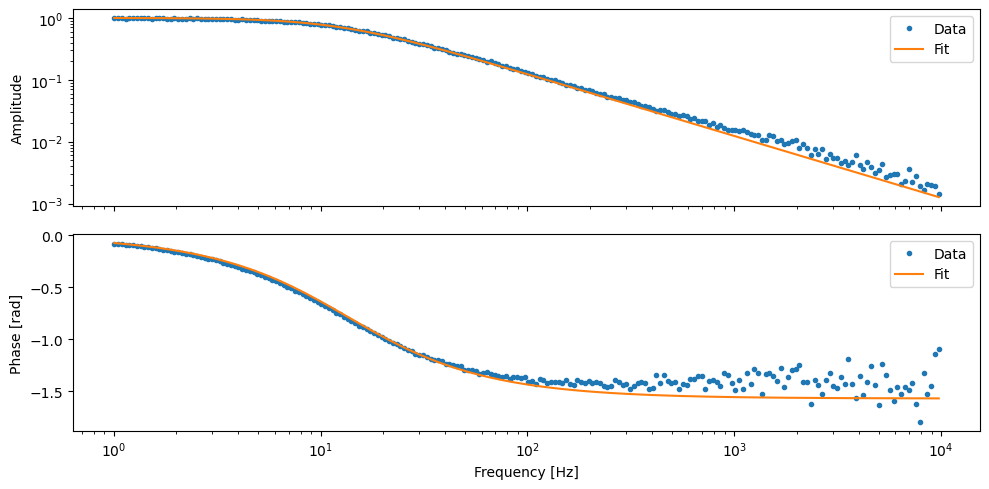

[77.84032456]
[85.06732791]


In [37]:
# Plot your fits with the data
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(freqs[mask], amp_abs[mask], '.', label='Data')
ax[0].plot(freqs[mask], amp_response(omegas[mask], *popt_amp), '-', label='Fit')
ax[0].set_ylabel('Amplitude')
ax[0].set_xscale('log') # shared x-axis, so only set it on one subplot
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(freqs[mask], phase_rad[mask], '.', label='Data')
ax[1].plot(freqs[mask], phase_response(omegas[mask], *popt_phase), '-', label='Fit')
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel('Phase [rad]')
ax[1].legend()

fig.tight_layout()
plt.show()
print(popt_amp);
print(popt_phase);